<a href="https://colab.research.google.com/github/LOVELY1907/SAP_AI-ML-DL/blob/main/03_Deep_Learning/SVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score

In [ ]:
#data Ingestion
df = pd.read_csv("/content/Pass-Fail Data.csv")

In [ ]:
df.sample(5)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
43,44,51,49,53,4,0
46,47,82,86,84,10,1
99,100,52,50,53,4,0
86,87,48,44,49,3,0
49,50,71,69,67,7,1


In [ ]:
def Data_cleaning(df):
  #null values
  null_values = df.isnull().sum()
  print(null_values)
  #duplicate values
  duplicate_values = df.duplicated().sum()
  print(duplicate_values)
  #information of data
  df.info()
  #describe
  df.describe()

In [ ]:
#calling function
Data_cleaning(df)

student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


In [ ]:
df.isnull().sum()

,0
student_id,0
attendance_pct,0
homework_pct,0
midterm_score,0
study_hours_per_week,0
pass,0


In [ ]:
df.drop('student_id',axis=1,inplace=True)

In [ ]:
#model building
x = df.drop('pass',axis=1)
y = df['pass']

In [ ]:
#training as testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=100,stratify=y)

In [ ]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [ ]:
lr1 = LinearRegression()
lr1.fit(x_train_scaled,y_train)

LinearRegression()

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(criterion='gini',random_state=42,max_depth=5)

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(lr,x_train_scaled,y_train,cv=5)

array([1., 1., 1., 1., 1.])

In [ ]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(lr,x_train_scaled,y_train,cv=10)
print(score.mean())
print(score.min())
print(score.max())

1.0
1.0
1.0


In [ ]:
y_pred = lr.predict(x_test_scaled)

In [ ]:
y_pred

array([1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)


1.0

In [ ]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
lgr = LogisticRegression(max_iter=1000)
dtc = DecisionTreeClassifier(max_depth=None,random_state=42,class_weight='balanced')
rfc = RandomForestClassifier(n_estimators=100,max_depth=None,random_state=42,class_weight='balanced')

In [ ]:
dtc = DecisionTreeClassifier(max_depth=None, random_state=42, class_weight='balanced')
dtc.fit(x_train_scaled, y_train)
y_pred=dtc.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

In [ ]:
rfc=RandomForestClassifier(n_estimators=100,max_depth=None,random_state=42,class_weight='balanced')
rfc.fit(x_train_scaled,y_train)
y_pred=rfc.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

In [ ]:
rfc.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
#fetch the important features Based on rfc
feature_importance = rfc.feature_importances_
feature_names = x_train.columns
new_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
new_df = new_df.sort_values(by='Importance', ascending=False)
print(new_df)

                Feature  Importance
0        attendance_pct        0.33
1          homework_pct        0.30
3  study_hours_per_week        0.25
2         midterm_score        0.12


In [ ]:
from sklearn.metrics import recall_score
recall_score(y_test,y_pred)

1.0

In [ ]:
#Principle component Analysis
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [ ]:
rfc1=RandomForestClassifier(n_estimators=100,max_depth=None,random_state=42,class_weight='balanced')

In [ ]:
rfc1.fit(x_train_pca,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

In [ ]:
recall_score(y_test,y_pred)

1.0

In [ ]:
from sklearn.svm import SVC
sfc = SVC()
sfc.fit(x_train_scaled,y_train)

SVC()

In [ ]:
accuracy_score(sfc.predict(x_test_scaled),y_test)

1.0

In [ ]:
recall_score(sfc.predict(x_test_scaled),y_test)

1.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step


<Axes: >

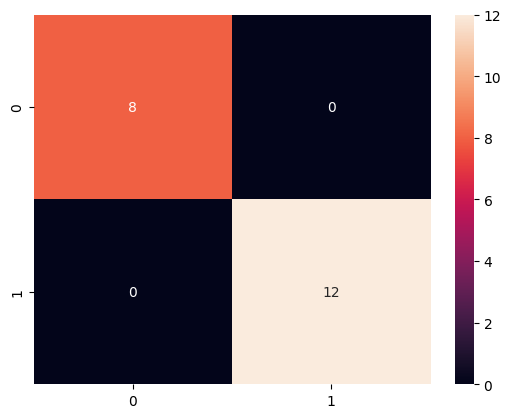

In [ ]:
from sklearn.metrics import confusion_matrix,recall_score
import tensorflow as tf

# Convert ANN's continuous predictions (logits) to binary labels
y_pred_ann = (tf.sigmoid(ANN1.predict(x_test_scaled)) > 0.5).numpy().astype(int)

confusion_obj = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(confusion_obj, annot=True)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model

In [ ]:
#creating a ANN network
ANN1 = Sequential()
ANN1.add(layers.Dense(64, activation='relu',input_shape=(x_train.shape[1],)))
ANN1.add(layers.Dense(32, activation='relu'))
ANN1.add(layers.Dense(16, activation='relu'))
ANN1.add(layers.Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ANN1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
ANN1.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), metrics=['accuracy'])
ANN1_history = ANN1.fit(x_train_scaled,y_train, epochs=100,validation_data=(x_test_scaled,y_test))

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.5813 - loss: 0.6423 - val_accuracy: 0.7000 - val_loss: 0.6097
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6664 - loss: 0.6013 - val_accuracy: 0.8000 - val_loss: 0.5604
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7359 - loss: 0.5645 - val_accuracy: 0.8000 - val_loss: 0.5147
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7820 - loss: 0.5107 - val_accuracy: 0.8500 - val_loss: 0.4721
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8023 - loss: 0.4820 - val_accuracy: 0.8500 - val_loss: 0.4355
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8242 - loss: 0.4442 - val_accuracy: 0.8500 - val_loss: 0.4010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8461 - loss: 0.4107 - val_accuracy: 0.8500 - val_loss: 0.3694
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8172 - loss: 0.3954 - val_accuracy: 0.8500 - val_loss

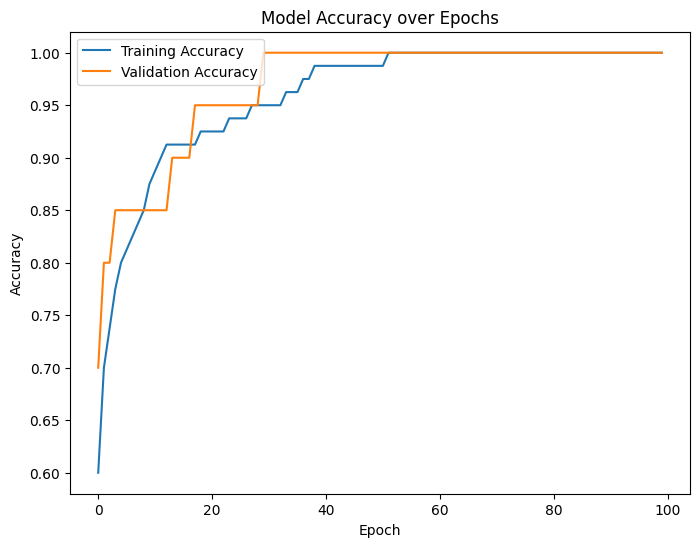

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(ANN1_history.history['accuracy'])
plt.plot(ANN1_history.history['val_accuracy'])
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='upper left')
plt.show()

In [ ]:
from sklearn.metrics import r2_score

y_pred = ANN1.predict(x_test)
print('The accuracy', r2_score(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
The accuracy -2561685.0


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
Y_pred1 = lr.predict(x_test)
print('The accuracy',r2_score(y_test, Y_pred1))

The accuracy 0.7556663487108464
